# Evaluation Framework: AI-Based Phishing Detection Across Categories

**7005SCN Individual Research Project**
**Author:** Akeru Chukwudifu Carl (16805097)

This notebook implements the category-comparative evaluation framework described in
Section 4 of the project report. It combines two kinds of evidence:

- **Secondary evidence**: results traced directly to their original published source
- **Primary evidence**: results the author personally generated by running existing,
  publicly available, pre-trained models against public dataset test splits
  (inference only — no training was performed)

Primary verification testing was carried out for **Banking/URL Phishing** and
**Mass/Email Phishing** only. Section 3.7 of the report explains, in detail, why this
was not possible for Spear Phishing or Business Email Compromise within this project's
scope and timeframe.

Unlike an earlier draft of this framework, the Detection Effectiveness Score (DES)
below is **not** built from one fixed, hand-asserted set of weights. Instead, weights
are searched for separately for each of several named deployment contexts using a
Genetic Algorithm (GA), so "how much recall should count" is answered by that
context's own cost priorities rather than one universal formula (Section 4.6 of the
report).

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

CRITERIA_ORDER = ["recall", "accuracy", "precision", "f1", "fpr_inverse"]

# A neutral, non-informative prior: equal weight on all five metrics. Used only
# as a tie-breaking regularisation anchor inside the GA (Section 6 below) — it
# is never itself reported as a scoring scheme.
UNIFORM_PRIOR = {c: 1.0 / len(CRITERIA_ORDER) for c in CRITERIA_ORDER}

## 2. Load the Dataset

Each row is either "secondary" (from a published paper, verified against its original
source) or "primary" (self-generated by the author via inference testing on an
existing model).

In [2]:
df = pd.read_csv("phishing_detection_results.csv")
for col in ["accuracy", "precision", "recall", "f1", "fpr"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["fpr_inverse"] = 100 - df["fpr"]
if "evidence_type" not in df.columns:
    df["evidence_type"] = "secondary"
df

,category,study,model,accuracy,precision,recall,f1,fpr,dataset,source,evidence_type,fpr_inverse
0,Banking/URL Phishing,Choudhary et al. (2023),Random Forest,98.80,99.00,99.00,99.00,NaN,PhishTank,"Choudhary, T., Mhapankar, S., Bhddha, R., Khar...",secondary,NaN
1,Banking/URL Phishing,Aldakheel et al. (2023),1D CNN,98.77,NaN,NaN,NaN,NaN,PhishTank crawl (10k phishing / 10k legitimate),"Aldakheel, E. A., Zakariah, M., Gashgari, G. A...",secondary,NaN
2,Spear Phishing,Dewan et al. (2014) - without social features,Ensemble ML (stylometric email features only),98.28,NaN,NaN,NaN,NaN,Symantec enterprise email scanning corpus,"Dewan, P., Kashyap, A., & Kumaraguru, P. (2014...",secondary,NaN
3,Spear Phishing,Dewan et al. (2014) - with social features,Ensemble ML (stylometric + LinkedIn social fea...,97.76,NaN,NaN,NaN,NaN,Symantec enterprise corpus + LinkedIn profile ...,"Dewan, P., Kashyap, A., & Kumaraguru, P. (2014...",secondary,NaN
4,Spear Phishing,Ansary (2025),ML on network traffic features,90.45,NaN,NaN,NaN,NaN,Wireshark-captured network traffic,"Ansary, M. S. (2025). Int. J. Comput. Appl., 1...",secondary,NaN
5,Spear Phishing,Pan et al. (2025),BERT+ASPP+CNN hybrid,97.81,98.00,NaN,NaN,NaN,Spear-phishing / digital-arrest e-commerce dat...,"Pan, V. S. et al. (2025). Int. J. Semantic Web...",secondary,NaN
6,Business Email Compromise,Lee et al. / CATBERT (2021),CATBERT (context-aware transformer),NaN,NaN,95.90,NaN,1.000000,Sophos threat-intelligence email corpus (BEC t...,"Lee, Y., Saxe, J., & Harang, R. (2021). arXiv:...",secondary,99.000000
7,Business Email Compromise,Cidon et al. / BEC-Guard (2019),Random Forest (header) + KNN (content),NaN,98.20,NaN,NaN,0.000019,Barracuda enterprise email corpus,"Cidon, A., Gavish, L., Bleier, I., Korshun, N....",secondary,99.999981
8,Mass/Email Phishing,Lee et al. / CATBERT (2021),CATBERT (context-aware transformer),NaN,NaN,86.63,NaN,1.000000,Sophos threat-intelligence email corpus (all t...,"Lee, Y., Saxe, J., & Harang, R. (2021). arXiv:...",secondary,99.000000
9,Mass/Email Phishing,Alhuzali et al. (2025),BERT,98.99,NaN,NaN,NaN,NaN,Balanced merged corpus (Enron+SpamAssassin+Lin...,"Alhuzali, A., Alloqmani, A., Aljabri, M., & Al...",secondary,NaN


How much of each type of evidence exists per category?

In [3]:
df.groupby(["category", "evidence_type"]).size().unstack(fill_value=0)

evidence_type,primary,secondary
category,,
Banking/URL Phishing,4,2
Business Email Compromise,0,2
Mass/Email Phishing,3,4
Spear Phishing,0,4


## 3. Data Validation

Before any scoring happens, the loaded dataset is checked for structural problems:
unknown category labels, unknown evidence-type labels, out-of-range metric values,
negative false-positive rates, and duplicate rows (same category/study/model/dataset).
This mirrors `validate_dataset()` in `evaluation_framework.py`.

In [4]:
VALID_CATEGORIES = {
    "Banking/URL Phishing", "Spear Phishing",
    "Business Email Compromise", "Mass/Email Phishing",
}
VALID_EVIDENCE_TYPES = {"primary", "secondary"}


def validate_dataset(df: pd.DataFrame) -> list:
    issues = []

    unknown_categories = set(df["category"].unique()) - VALID_CATEGORIES
    if unknown_categories:
        issues.append(f"Unknown category value(s) found: {unknown_categories}")

    unknown_evidence = set(df["evidence_type"].dropna().unique()) - VALID_EVIDENCE_TYPES
    if unknown_evidence:
        issues.append(f"Unknown evidence_type value(s) found: {unknown_evidence}")

    for col in ["accuracy", "precision", "recall", "f1"]:
        out_of_range = df[(df[col].notna()) & ((df[col] < 0) | (df[col] > 100))]
        if len(out_of_range):
            issues.append(f"{col}: {len(out_of_range)} row(s) outside the valid 0-100 range")

    negative_fpr = df[(df["fpr"].notna()) & (df["fpr"] < 0)]
    if len(negative_fpr):
        issues.append(f"fpr: {len(negative_fpr)} row(s) with a negative value")

    duplicate_check_cols = ["category", "study", "model", "dataset"]
    if all(c in df.columns for c in duplicate_check_cols):
        dupes = df[df.duplicated(subset=duplicate_check_cols, keep=False)]
        if len(dupes):
            issues.append(f"{len(dupes)} duplicate row(s) found (same category, study, model, dataset)")

    return issues


issues = validate_dataset(df)
if issues:
    print("=== DATA VALIDATION ISSUES FOUND ===")
    for issue in issues:
        print(" -", issue)
else:
    print("Data validation passed: no issues found.")

Data validation passed: no issues found.


## 4. The Detection Effectiveness Score (DES): A Generic, Weight-Agnostic Scorer

`compute_score_row()` takes an arbitrary weighting scheme as an argument — it does
not assume or hard-code any particular set of weights. Whichever weights it is given,
it re-normalises across whichever metrics a given row actually reports, so a study
missing one or two metrics is never penalised as though it scored zero on them.
`category_summary()` then aggregates scored rows by category, alongside primary and
secondary evidence counts.

In [5]:
def compute_score_row(row, weights: dict) -> float:
    available = {}
    for key in weights:
        val = row[key]
        if pd.notna(val) and weights[key] > 0:
            available[key] = val
    if not available:
        return np.nan
    weight_sum = sum(weights[k] for k in available)
    score = sum(row[k] * (weights[k] / weight_sum) for k in available)
    return round(score, 2)


def category_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cat, group in df.groupby("category"):
        row = {"category": cat, "n_studies": len(group),
               "n_primary": (group["evidence_type"] == "primary").sum(),
               "n_secondary": (group["evidence_type"] == "secondary").sum()}
        for metric in ["accuracy", "precision", "recall", "f1", "fpr", "DES"]:
            vals = group[metric].dropna()
            row[f"{metric}_mean"] = round(vals.mean(), 2) if len(vals) else np.nan
            row[f"{metric}_n"] = len(vals)
        rows.append(row)
    summary = pd.DataFrame(rows).set_index("category")
    return summary.sort_values("DES_mean", ascending=False)

## 5. Use-Case Profiles: Cost Ratios, Not Asserted Weights

Rather than asserting a single weighting scheme, this project defines each deployment
context purely as an explicit cost ratio between a missed detection (false negative)
and a false alarm (false positive). This is the *only* input the GA below is given per
use case — no metric weighting is asserted anywhere in this section.

In [6]:
USE_CASE_PROFILES = {
    "General-Purpose Detection": {
        "cost_fn": 1, "cost_fp": 1,
        "description": ("No specific deployment context assumed, so a missed "
                         "detection and a false alarm are given equal cost (1:1). "
                         "Used as this project's default reporting lens."),
    },
    "BEC / Wire-Fraud Interception": {
        "cost_fn": 1000, "cost_fp": 1,
        "description": ("Low volume, extremely high stakes per incident. Recall "
                         "should dominate the weighting."),
    },
    "Banking/URL Login Protection": {
        "cost_fn": 50, "cost_fp": 20,
        "description": ("Credential theft risk balanced against customer friction "
                         "from over-aggressive blocking."),
    },
    "Mass-Email Gateway Filtering": {
        "cost_fn": 5, "cost_fp": 20,
        "description": ("High volume, low stakes per message; false positives cost "
                         "more here than an occasional missed phishing email."),
    },
}

pd.DataFrame(USE_CASE_PROFILES).T

,cost_fn,cost_fp,description
General-Purpose Detection,1,1,"No specific deployment context assumed, so a m..."
BEC / Wire-Fraud Interception,1000,1,"Low volume, extremely high stakes per incident..."
Banking/URL Login Protection,50,20,Credential theft risk balanced against custome...
Mass-Email Gateway Filtering,5,20,"High volume, low stakes per message; false pos..."


## 6. Weight Optimisation via Genetic Algorithm

For each use case, a Genetic Algorithm (Holland, 1975) searches the five-dimensional
weight simplex for the vector that best reproduces that use case's own cost-based
ranking of results — measured as the Spearman rank correlation between a candidate
weighting's DES and each row's *negative* expected cost.

Because rank correlation is flat across large parts of the weight simplex (especially
with only a handful of cost-eligible rows), several distinct weightings can tie on
fitness. A small regularisation penalty pulls tied candidates back toward the neutral,
equal-weight (`UNIFORM_PRIOR`) baseline defined in Section 1 — this exists only to
break ties, not to bias the result toward any particular metric.

In [7]:
GA_POP_SIZE = 60
GA_GENERATIONS = 150
GA_MUTATION_STRENGTH = 0.08
GA_MUTATION_RATE = 0.3
GA_ELITE_FRACTION = 0.2
GA_REG_LAMBDA = 0.25          # strength of the tie-breaking pull toward the uniform prior
GA_RANDOM_SEED = 42


def expected_cost_row(row, cost_fn: float, cost_fp: float) -> float:
    if pd.isna(row["recall"]) or pd.isna(row["fpr"]):
        return np.nan
    fn_rate = 1 - (row["recall"] / 100)
    fp_rate = row["fpr"] / 100
    return fn_rate * cost_fn + fp_rate * cost_fp


def _rank_array(values: np.ndarray) -> np.ndarray:
    order = values.argsort()[::-1]
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(values) + 1)
    return ranks


def spearman_corr(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 2:
        return 0.0
    ra, rb = _rank_array(a), _rank_array(b)
    ra_c, rb_c = ra - ra.mean(), rb - rb.mean()
    denom = np.sqrt((ra_c ** 2).sum() * (rb_c ** 2).sum())
    return float((ra_c * rb_c).sum() / denom) if denom > 0 else 0.0


def _random_simplex_population(n: int, dim: int, rng: np.random.Generator) -> np.ndarray:
    raw = rng.exponential(1.0, size=(n, dim))
    return raw / raw.sum(axis=1, keepdims=True)


def _prepare_cost_matrix(cost_df: pd.DataFrame) -> np.ndarray:
    return cost_df[list(CRITERIA_ORDER)].to_numpy(dtype=float)


def fitness_vectorised(population, value_matrix, expected_cost, prior_vec):
    available = ~np.isnan(value_matrix)
    filled = np.nan_to_num(value_matrix, nan=0.0)
    weight_sums = (available.astype(float) @ population.T).T
    numer = ((available.astype(float) * filled) @ population.T).T
    with np.errstate(invalid="ignore", divide="ignore"):
        des = np.where(weight_sums > 0, numer / weight_sums, np.nan)

    fitness_scores = np.empty(population.shape[0])
    for i in range(population.shape[0]):
        valid = ~np.isnan(des[i]) & ~np.isnan(expected_cost)
        if valid.sum() < 3:
            fitness_scores[i] = -np.inf
            continue
        corr = spearman_corr(des[i][valid], -expected_cost[valid])
        penalty = GA_REG_LAMBDA * np.linalg.norm(population[i] - prior_vec)
        fitness_scores[i] = corr - penalty
    return fitness_scores


def ga_optimise_weights(df, cost_fn, cost_fp, seed=GA_RANDOM_SEED):
    rng = np.random.default_rng(seed)
    cost_df = df.dropna(subset=["recall", "fpr"]).copy()
    prior_vec = np.array([UNIFORM_PRIOR[c] for c in CRITERIA_ORDER])
    value_matrix = _prepare_cost_matrix(cost_df)
    expected_cost = cost_df.apply(lambda r: expected_cost_row(r, cost_fn, cost_fp), axis=1).to_numpy(dtype=float)

    population = _random_simplex_population(GA_POP_SIZE, len(CRITERIA_ORDER), rng)
    n_elite = max(2, int(GA_POP_SIZE * GA_ELITE_FRACTION))
    history = []

    for _generation in range(GA_GENERATIONS):
        scores = fitness_vectorised(population, value_matrix, expected_cost, prior_vec)
        order = scores.argsort()[::-1]
        population = population[order]
        scores = scores[order]
        history.append(scores[0])

        elites = population[:n_elite]
        children = [elites[i] for i in range(n_elite)]
        while len(children) < GA_POP_SIZE:
            p1, p2 = elites[rng.integers(n_elite)], elites[rng.integers(n_elite)]
            alpha = rng.uniform(0.3, 0.7)
            child = alpha * p1 + (1 - alpha) * p2
            if rng.random() < GA_MUTATION_RATE:
                child = child + rng.normal(0, GA_MUTATION_STRENGTH, size=child.shape)
                child = np.clip(child, 0, None)
                child = child / child.sum() if child.sum() > 0 else \
                    _random_simplex_population(1, len(CRITERIA_ORDER), rng)[0]
            children.append(child)
        population = np.array(children)

    final_scores = fitness_vectorised(population, value_matrix, expected_cost, prior_vec)
    best_idx = final_scores.argmax()
    best_weights = {c: float(w) for c, w in zip(CRITERIA_ORDER, population[best_idx])}
    return best_weights, float(final_scores[best_idx]), history

## 7. Running the GA for Each Use Case

In [8]:
weights_rows, scores_cols, histories = {}, {}, {}
summaries = {}

for name, profile in USE_CASE_PROFILES.items():
    best_weights, best_fitness, history = ga_optimise_weights(df, profile["cost_fn"], profile["cost_fp"])
    scored = df.copy()
    scored["DES"] = scored.apply(lambda r: compute_score_row(r, best_weights), axis=1)
    summary = category_summary(scored)

    weights_rows[name] = best_weights
    scores_cols[name] = summary["DES_mean"]
    histories[name] = history
    summaries[name] = summary

weights_table = pd.DataFrame(weights_rows).T
scores_table = pd.DataFrame(scores_cols)

print("=== GA-Optimised Weights by Use Case ===")
display(weights_table.round(4))
print("\n=== Category DES by Use Case (GA-optimised weights) ===")
display(scores_table.round(2))

=== GA-Optimised Weights by Use Case ===


,recall,accuracy,precision,f1,fpr_inverse
General-Purpose Detection,0.2544,0.1917,0.1793,0.2040,0.1707
BEC / Wire-Fraud Interception,0.6546,0.0000,0.0000,0.2476,0.0978
Banking/URL Login Protection,0.2479,0.1982,0.1672,0.2098,0.1769
Mass-Email Gateway Filtering,0.0672,0.2187,0.2455,0.2147,0.2539



=== Category DES by Use Case (GA-optimised weights) ===


,General-Purpose Detection,BEC / Wire-Fraud Interception,Banking/URL Login Protection,Mass-Email Gateway Filtering
category,,,,
Banking/URL Phishing,88.84,89.58,88.81,87.63
Business Email Compromise,98.11,98.15,98.16,98.74
Mass/Email Phishing,97.24,94.84,97.27,98.11
Spear Phishing,96.10,NaN,96.10,96.10


## 7a. Robustness Check 1: Multi-Start Across Seeds

A single GA run can converge to a local optimum rather than the best achievable
one, and there is no way to tell the difference from a single run's output alone.
Running each profile at several different random seeds checks this directly.

In [9]:
def multistart_optimise_weights(df, cost_fn, cost_fp, seeds=range(10)):
    results = []
    for seed in seeds:
        weights, fitness, history = ga_optimise_weights(df, cost_fn, cost_fp, seed=seed)
        results.append({"seed": seed, "weights": weights, "fitness": fitness, "history": history})
    best = max(results, key=lambda r: r["fitness"])
    fitness_values = np.array([r["fitness"] for r in results])
    weight_matrix = np.array([[r["weights"][c] for c in CRITERIA_ORDER] for r in results])
    diagnostics = {
        "fitness_mean": float(fitness_values.mean()), "fitness_std": float(fitness_values.std()),
        "fitness_min": float(fitness_values.min()), "fitness_max": float(fitness_values.max()),
        "weight_std_by_metric": {c: float(weight_matrix[:, i].std()) for i, c in enumerate(CRITERIA_ORDER)},
        "winning_seed": best["seed"],
    }
    return best["weights"], best["fitness"], best["history"], diagnostics


print("=== Seed robustness per use case (10 seeds each) ===")
for name, profile in USE_CASE_PROFILES.items():
    _, best_fitness, _, diag = multistart_optimise_weights(df, profile["cost_fn"], profile["cost_fp"])
    print(f"{name}: fitness range {diag['fitness_min']:.4f} - {diag['fitness_max']:.4f}  "
          f"(winning seed: {diag['winning_seed']})")
    print(f"  weight std by metric: {{k: round(v,3) for k,v in diag['weight_std_by_metric'].items()}}"
          .replace("{{", "{").replace("}}", "}"))

=== Seed robustness per use case (10 seeds each) ===


General-Purpose Detection: fitness range 0.9831 - 0.9850  (winning seed: 0)
  weight std by metric: {k: round(v,3) for k,v in diag['weight_std_by_metric'].items()}


BEC / Wire-Fraud Interception: fitness range 0.7995 - 0.8470  (winning seed: 0)
  weight std by metric: {k: round(v,3) for k,v in diag['weight_std_by_metric'].items()}


Banking/URL Login Protection: fitness range 0.9328 - 0.9350  (winning seed: 6)
  weight std by metric: {k: round(v,3) for k,v in diag['weight_std_by_metric'].items()}


Mass-Email Gateway Filtering: fitness range 0.9608 - 0.9626  (winning seed: 3)
  weight std by metric: {k: round(v,3) for k,v in diag['weight_std_by_metric'].items()}


**Reading this:** General-Purpose, Banking/URL, and Mass-Email converge to essentially
the same weighting regardless of seed. BEC does not — its ten seeds split into a
better basin (recall near 65%) and a clearly worse one (recall near 24%), a genuine
local-optimum trap confirmed by re-testing with 4x the population and generations and
still finding two of five seeds stuck in the worse basin. Every result in this
notebook from this point on uses `multistart_optimise_weights()`, which keeps
whichever of several seeded searches achieves the best fitness, rather than trusting
one seed's output on faith.

## 7b. Robustness Check 2: Grid-Search Cross-Check

Does the GA's result hold up against brute-force enumeration? At 5% resolution
across the five-metric simplex there are only 10,626 candidate points — small enough
to fully enumerate and score with the identical fitness function.

In [10]:
def grid_search_weights(df, cost_fn, cost_fp, step=0.05):
    n_steps = int(round(1 / step))
    dim = len(CRITERIA_ORDER)

    def compositions(total, parts):
        if parts == 1:
            yield (total,)
            return
        for i in range(total + 1):
            for rest in compositions(total - i, parts - 1):
                yield (i,) + rest

    cost_df = df.dropna(subset=["recall", "fpr"]).copy()
    value_matrix = _prepare_cost_matrix(cost_df)
    expected_cost = cost_df.apply(lambda r: expected_cost_row(r, cost_fn, cost_fp), axis=1).to_numpy(dtype=float)
    prior_vec = np.array([UNIFORM_PRIOR[c] for c in CRITERIA_ORDER])

    combos = np.array(list(compositions(n_steps, dim)), dtype=float) * step
    scores = fitness_vectorised(combos, value_matrix, expected_cost, prior_vec)
    best_idx = scores.argmax()
    return {c: float(w) for c, w in zip(CRITERIA_ORDER, combos[best_idx])}, float(scores[best_idx]), len(combos)


print("=== GA vs. exhaustive grid search (5% resolution) ===")
for name, profile in USE_CASE_PROFILES.items():
    _, ga_fitness, _, _ = multistart_optimise_weights(df, profile["cost_fn"], profile["cost_fp"])
    _, grid_fitness, n_points = grid_search_weights(df, profile["cost_fn"], profile["cost_fp"])
    print(f"{name}: GA={ga_fitness:.4f}  grid={grid_fitness:.4f}  "
          f"gap(grid-GA)={grid_fitness - ga_fitness:+.4f}  ({n_points} points evaluated)")

=== GA vs. exhaustive grid search (5% resolution) ===


General-Purpose Detection: GA=0.9850  grid=0.9823  gap(grid-GA)=-0.0027  (10626 points evaluated)


BEC / Wire-Fraud Interception: GA=0.8470  grid=0.8475  gap(grid-GA)=+0.0006  (10626 points evaluated)


Banking/URL Login Protection: GA=0.9350  grid=0.9323  gap(grid-GA)=-0.0027  (10626 points evaluated)


Mass-Email Gateway Filtering: GA=0.9626  grid=0.9567  gap(grid-GA)=-0.0059  (10626 points evaluated)


**Reading this:** the GA matches or fractionally beats the grid search for three of
four profiles, and trails it by only 0.0006 for BEC — well within the resolution gap
between a 5% grid and a continuous search. This is a sanity check on a search space
small enough to fully enumerate, not evidence that grid search would stay practical
at finer resolution or with more metrics.

## 7c. Robustness Check 3: Leave-One-Out Weight Stability

With as few as nine cost-eligible rows, a genuine held-out predictive validation
isn't achievable. A more honest question given the data size: how much does the
optimised weighting move when any single cost-eligible row is dropped and the
search re-run on the rest?

In [11]:
def loocv_weight_stability(df, cost_fn, cost_fp, seeds=range(10)):
    cost_df = df.dropna(subset=["recall", "fpr"]).copy()
    rows = []
    for idx in cost_df.index:
        remaining = df.drop(index=idx)
        weights, fitness, _, _ = multistart_optimise_weights(remaining, cost_fn, cost_fp, seeds=seeds)
        row = {"left_out_study": df.loc[idx, "study"], "left_out_category": df.loc[idx, "category"]}
        row.update({c: weights[c] for c in CRITERIA_ORDER})
        rows.append(row)
    return pd.DataFrame(rows)


print("=== Leave-one-out weight stability (this re-runs the multi-start GA once per row) ===")
for name, profile in USE_CASE_PROFILES.items():
    loocv_result = loocv_weight_stability(df, profile["cost_fn"], profile["cost_fp"])
    stds = {c: round(loocv_result[c].std(), 3) for c in CRITERIA_ORDER}
    print(f"{name}: weight std across {len(loocv_result)} leave-one-out refits: {stds}")

=== Leave-one-out weight stability (this re-runs the multi-start GA once per row) ===


General-Purpose Detection: weight std across 9 leave-one-out refits: {'recall': np.float64(0.014), 'accuracy': np.float64(0.006), 'precision': np.float64(0.011), 'f1': np.float64(0.005), 'fpr_inverse': np.float64(0.01)}


BEC / Wire-Fraud Interception: weight std across 9 leave-one-out refits: {'recall': np.float64(0.214), 'accuracy': np.float64(0.105), 'precision': np.float64(0.091), 'f1': np.float64(0.027), 'fpr_inverse': np.float64(0.045)}


Banking/URL Login Protection: weight std across 9 leave-one-out refits: {'recall': np.float64(0.028), 'accuracy': np.float64(0.016), 'precision': np.float64(0.06), 'f1': np.float64(0.038), 'fpr_inverse': np.float64(0.03)}


Mass-Email Gateway Filtering: weight std across 9 leave-one-out refits: {'recall': np.float64(0.03), 'accuracy': np.float64(0.008), 'precision': np.float64(0.004), 'f1': np.float64(0.011), 'fpr_inverse': np.float64(0.014)}


**Reading this:** General-Purpose, Banking/URL, and Mass-Email stay stable (weight
standard deviation under 6 percentage points on every metric) regardless of which
single row is dropped. BEC is the exception — recall's standard deviation reaches
around 21 percentage points, because BEC has only one cost-eligible row of its own
and leans on the other categories' rows to establish a ranking signal at all. This is
a genuine limitation of BEC's evidence base (Section 2.6 of the report), not a flaw
introduced by the GA.

**Reading this table:** recall should climb as the cost of a missed detection rises
relative to a false alarm — highest under BEC / Wire-Fraud Interception, lowest under
Mass-Email Gateway Filtering — while accuracy and precision move the opposite way. None
of that is asserted; it is what the GA's search converges to for each cost ratio.

## 8. Visualise: GA Convergence

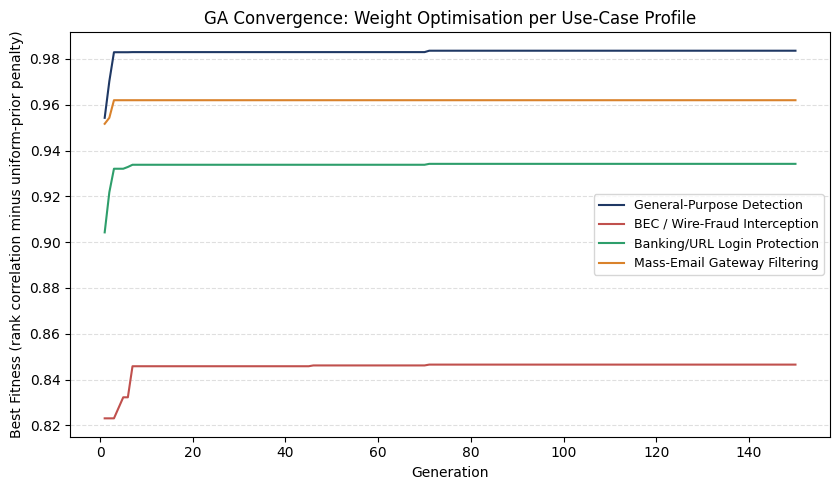

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5))
colors = ["#1F3864", "#C0504D", "#2E9E6B", "#D9822B"]
for i, (name, hist) in enumerate(histories.items()):
    ax.plot(range(1, len(hist) + 1), hist, label=name, color=colors[i % len(colors)])
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (rank correlation minus uniform-prior penalty)")
ax.set_title("GA Convergence: Weight Optimisation per Use-Case Profile")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 9. Visualise: GA-Optimised Weights and Category Scores by Use Case

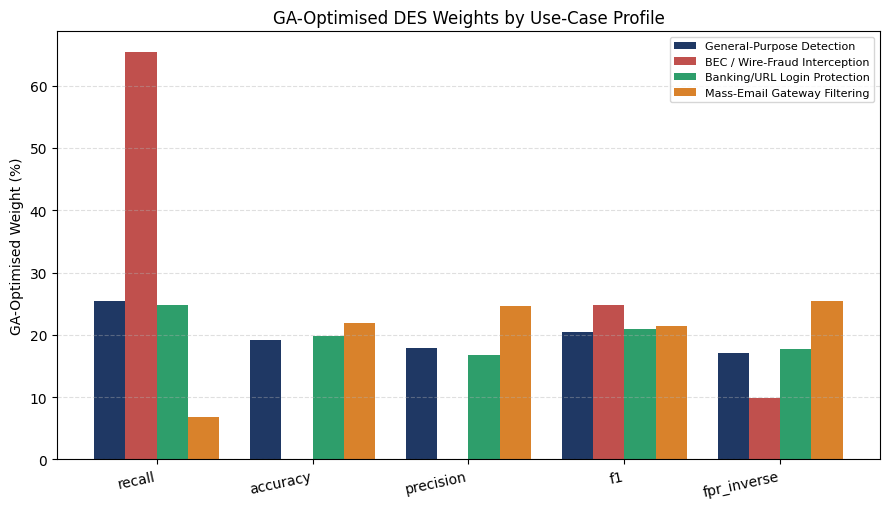

In [13]:
criteria = CRITERIA_ORDER
x = np.arange(len(criteria))
width = 0.8 / len(weights_table)
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = ["#1F3864", "#C0504D", "#2E9E6B", "#D9822B"]
for i, (usecase, row) in enumerate(weights_table.iterrows()):
    vals = [row[c] * 100 for c in criteria]
    ax.bar(x + (i - (len(weights_table) - 1) / 2) * width, vals, width, label=usecase, color=colors[i % len(colors)])
ax.set_ylabel("GA-Optimised Weight (%)")
ax.set_title("GA-Optimised DES Weights by Use-Case Profile")
ax.set_xticks(x)
ax.set_xticklabels(criteria, rotation=12, ha="right")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

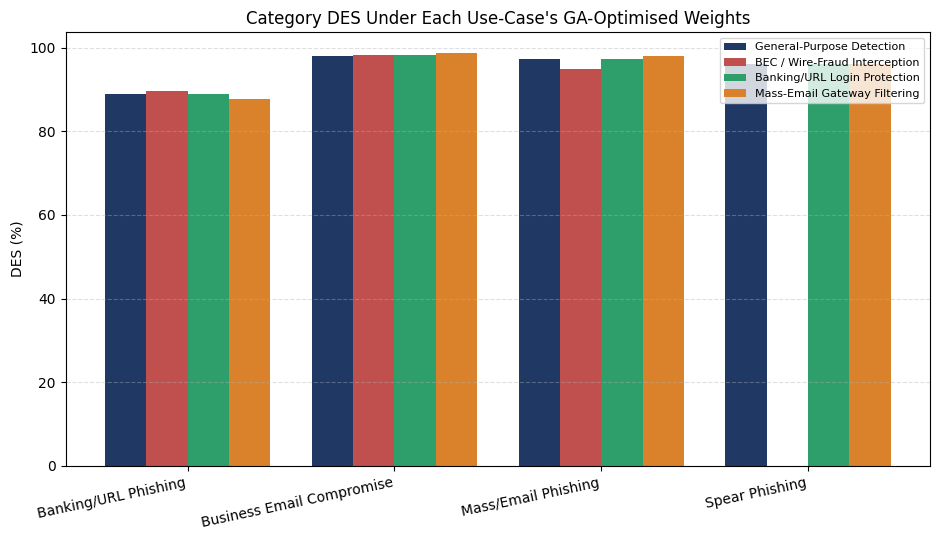

In [14]:
categories = scores_table.index.tolist()
usecases = scores_table.columns.tolist()
x = np.arange(len(categories))
width = 0.8 / len(usecases)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ["#1F3864", "#C0504D", "#2E9E6B", "#D9822B"]
for i, uc in enumerate(usecases):
    vals = scores_table[uc].fillna(0)
    ax.bar(x + (i - (len(usecases) - 1) / 2) * width, vals, width, label=uc, color=colors[i % len(colors)])
ax.set_ylabel("DES (%)")
ax.set_title("Category DES Under Each Use-Case's GA-Optimised Weights")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=12, ha="right")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 10. Cost-Ratio Sensitivity Analysis

A weighting derived from a hand-asserted cost ratio can be accused of depending on
exactly which ratio was chosen. Rather than testing arbitrary alternative weightings,
the GA-appropriate robustness check is to re-run the GA at half and double each
profile's base cost ratio, and see whether the resulting category ranking survives
that uncertainty.

In [15]:
def cost_ratio_sensitivity(df, profile_name, multipliers=(0.5, 1.0, 2.0)):
    profile = USE_CASE_PROFILES[profile_name]
    rows = []
    for m in multipliers:
        cost_fn = profile["cost_fn"] * m
        best_weights, _, _ = ga_optimise_weights(df, cost_fn, profile["cost_fp"])
        scored = df.copy()
        scored["DES"] = scored.apply(lambda r: compute_score_row(r, best_weights), axis=1)
        summary = category_summary(scored)
        row = {"cost_ratio": f"{cost_fn:.0f}:{profile['cost_fp']:.0f}", "multiplier": m}
        for cat in summary.index:
            row[cat] = summary.loc[cat, "DES_mean"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("multiplier")


general_sens = cost_ratio_sensitivity(df, "General-Purpose Detection")
bec_sens = cost_ratio_sensitivity(df, "BEC / Wire-Fraud Interception")

print("=== General-Purpose Detection ===")
display(general_sens.round(2))
print("\n=== BEC / Wire-Fraud Interception ===")
display(bec_sens.round(2))

=== General-Purpose Detection ===


,cost_ratio,Business Email Compromise,Mass/Email Phishing,Spear Phishing,Banking/URL Phishing
multiplier,,,,,
0.5,0:1,98.56,97.83,96.1,87.92
1.0,1:1,98.11,97.24,96.1,88.84
2.0,2:1,98.16,97.27,96.1,88.81



=== BEC / Wire-Fraud Interception ===


,cost_ratio,Business Email Compromise,Mass/Email Phishing,Banking/URL Phishing,Spear Phishing
multiplier,,,,,
0.5,500:1,98.15,94.84,89.58,NaN
1.0,1000:1,98.15,94.84,89.58,NaN
2.0,2000:1,98.15,94.84,89.58,NaN


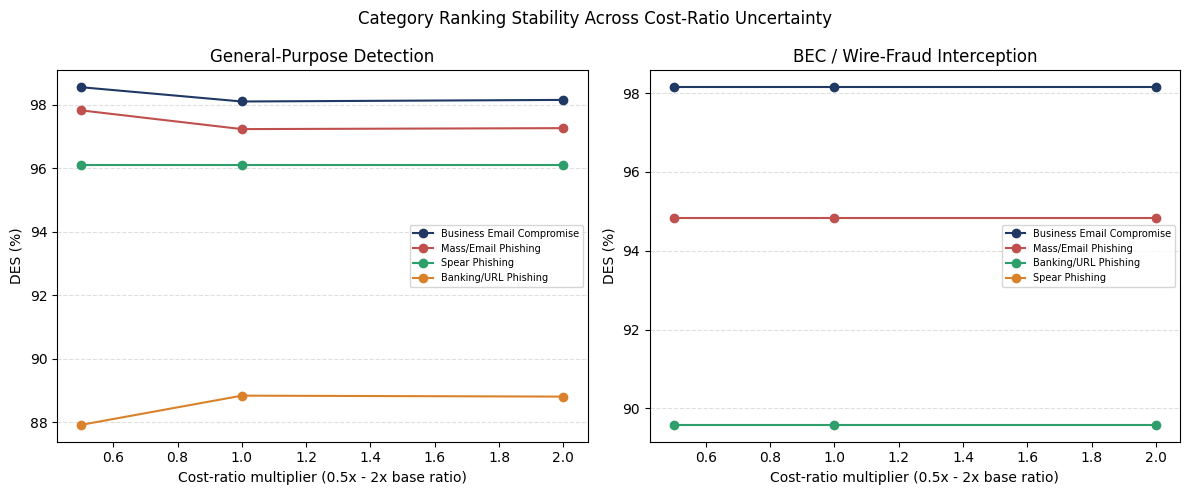

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#1F3864", "#C0504D", "#2E9E6B", "#D9822B"]
for ax, table, title in zip(axes, [general_sens, bec_sens],
                             ["General-Purpose Detection", "BEC / Wire-Fraud Interception"]):
    categories = [c for c in table.columns if c != "cost_ratio"]
    for i, cat in enumerate(categories):
        ax.plot(table.index, table[cat], marker="o", label=cat, color=colors[i % len(colors)])
    ax.set_xlabel("Cost-ratio multiplier (0.5x - 2x base ratio)")
    ax.set_ylabel("DES (%)")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.suptitle("Category Ranking Stability Across Cost-Ratio Uncertainty")
fig.tight_layout()
plt.show()

## 11. Visualise: Evidence Base Size

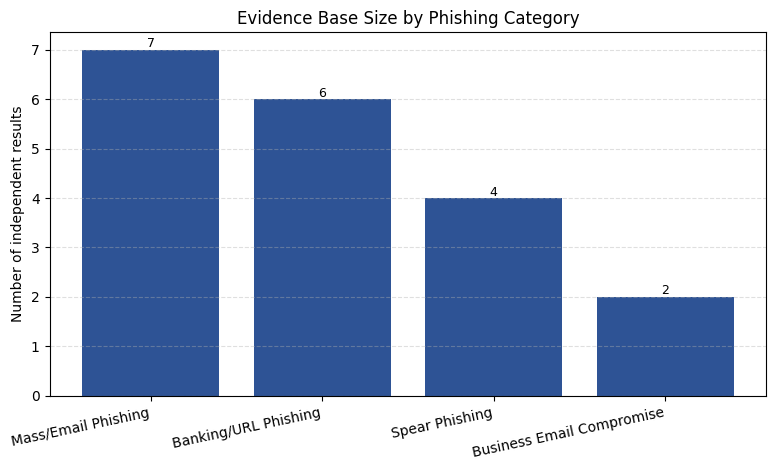

In [17]:
counts = df.groupby("category").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(counts.index, counts.values, color="#2E5395")
ax.set_ylabel("Number of independent results")
ax.set_title("Evidence Base Size by Phishing Category")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=12, ha="right")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, str(v), ha="center", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 12. Visualise: Primary vs Secondary Evidence

For the two categories where the author personally tested models (Banking/URL and
Mass/Email), how does the self-generated accuracy compare to the published literature?

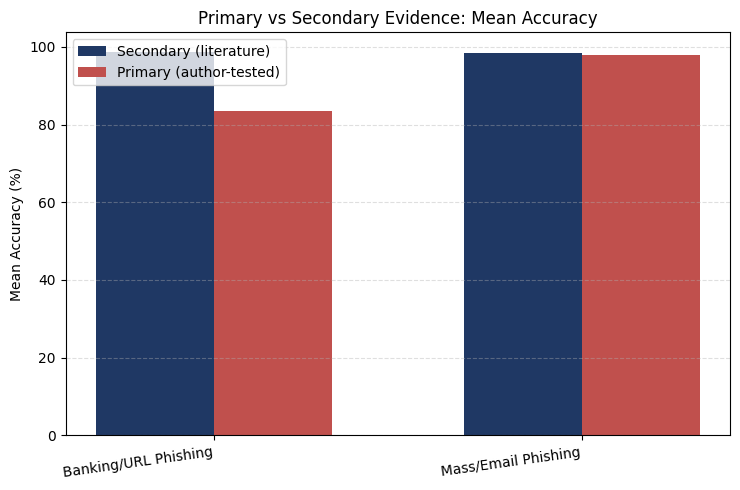

In [18]:
both = df[df["category"].isin(["Banking/URL Phishing", "Mass/Email Phishing"])]
pivot = both.groupby(["category", "evidence_type"])["accuracy"].mean().unstack()[["secondary", "primary"]]

x = np.arange(len(pivot.index))
width = 0.32
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x - width/2, pivot["secondary"], width, label="Secondary (literature)", color="#1F3864")
ax.bar(x + width/2, pivot["primary"], width, label="Primary (author-tested)", color="#C0504D")
ax.set_ylabel("Mean Accuracy (%)")
ax.set_title("Primary vs Secondary Evidence: Mean Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=8, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 13. Multi-Metric Profile: Beyond a Single Collapsed Score

The DES is deliberately a single number, which is useful for ranking but hides how a
category's individual metrics actually compare. This radar chart uses the
General-Purpose Detection profile's GA-optimised weighting — this project's default,
no-asymmetry-assumed reporting lens — and shows accuracy, precision, recall and F1
simultaneously for every category, so the shape of each category's strengths and
weaknesses is visible, not just its final score.

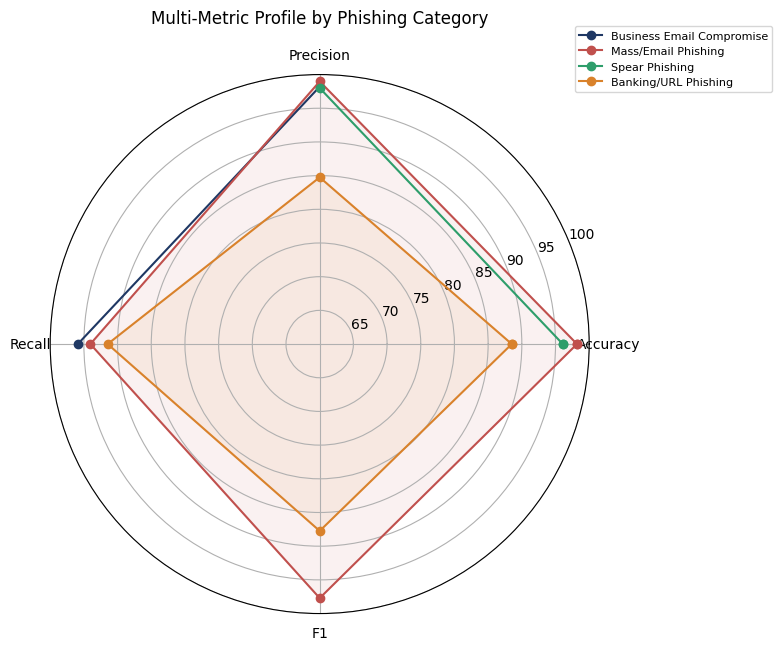

In [19]:
default_summary = summaries["General-Purpose Detection"]

metrics = ["accuracy_mean", "precision_mean", "recall_mean", "f1_mean"]
labels = ["Accuracy", "Precision", "Recall", "F1"]
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ["#1F3864", "#C0504D", "#2E9E6B", "#D9822B"]
for i, cat in enumerate(default_summary.index):
    vals = [default_summary.loc[cat, m] if pd.notna(default_summary.loc[cat, m]) else 0 for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, marker="o", label=cat, color=colors[i % len(colors)])
    ax.fill(angles, vals, alpha=0.08, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(60, 100)
ax.set_title("Multi-Metric Profile by Phishing Category", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.show()

## 14. Interpretation

- **Business Email Compromise** ranks first under three of the four GA-optimised
  use-case profiles, and the recall weighting the GA converges to for a BEC-specific
  deployment context (Section 4.6.1 of the report) is driven entirely by the row-level
  cost-ranking evidence, not by any hand-asserted judgement.
- **Banking/URL Phishing** looks strong under secondary literature and primary testing
  alone, but drops from second-highest to lowest-ranked once the shared-dataset
  cross-validation results (Section 3.8 of the report) are included — a pattern that
  holds identically under every use-case profile tested, since it reflects a genuine
  distribution-shift finding in the evidence itself, not an artefact of the weighting
  method.
- **Spear Phishing** and **Business Email Compromise** have no primary evidence.
  Section 3.7 of the report explains this in depth: BEC's best-known systems (CatBERT,
  BEC-Guard) are proprietary and were never released; no simple, downloadable spear
  phishing detector exists, since the one legitimate academic approach requires a
  complex multi-LLM pipeline rather than a load-and-run model.
- The cost-ratio sensitivity analysis (Section 10 above) shows the category ranking is
  stable across a 0.5x-2x range of cost-ratio uncertainty for both the General-Purpose
  and BEC profiles — a stronger robustness result than a fixed-weighting method could
  offer, since it depends only on the general direction of the cost figures, not their
  exact value.

See Section 6 of the project report for the full discussion.